## 1. Data Understanding and Exploratory Data Analysis

This notebook performs the initial data understanding and exploratory analysis of the UCI Default of Credit Card Clients dataset.

The main objectives are:
- Understand the dataset structure and variables
- Check data quality
- Analyze the target variable and class imbalance
- Investigate demographic and financial characteristics
- Analyze payment behavior
- Identify unusual values and potential outliers
- Understand relationships between features and credit default
- Identify useful insights for data cleaning and feature engineering

In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

file_path = "../data/raw/default of credit card clients.xls"

df = pd.read_excel(file_path, header=1)


print("Dataset loaded successfully.")

Dataset loaded successfully.


In [2]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [3]:
df.tail()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
29995,29996,220000,1,3,1,39,0,0,0,0,0,0,188948,192815,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,29997,150000,1,3,2,43,-1,-1,-1,-1,0,0,1683,1828,3502,8979,5190,0,1837,3526,8998,129,0,0,0
29997,29998,30000,1,2,2,37,4,3,2,-1,0,0,3565,3356,2758,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,29999,80000,1,3,1,41,1,-1,0,0,0,-1,-1645,78379,76304,52774,11855,48944,85900,3409,1178,1926,52964,1804,1
29999,30000,50000,1,2,1,46,0,0,0,0,0,0,47929,48905,49764,36535,32428,15313,2078,1800,1430,1000,1000,1000,1


In [4]:
# Dataset Dimensions

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Dataset shape:", df.shape)

Number of rows: 30000
Number of columns: 25
Dataset shape: (30000, 25)


In [5]:
# Column Names

df.columns.tolist()

['ID',
 'LIMIT_BAL',
 'SEX',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_0',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'default payment next month']

In [6]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_AMT3        

In [7]:
# Descriptive Statistics

df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


Missing Value Analysis

In [8]:
missing_values = df.isnull().sum()

print(missing_values)

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64


In [9]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [10]:
# Duplicate Records

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


Unique Values

In [11]:
for col in ["SEX", "EDUCATION", "MARRIAGE"]:
    print("=" * 50)
    print(col)
    print(sorted(df[col].unique()))

SEX
[np.int64(1), np.int64(2)]
EDUCATION
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
MARRIAGE
[np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


In [12]:
pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

for col in pay_cols:
    print("=" * 50)
    print(col)
    print(sorted(df[col].unique()))

PAY_0
[np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_2
[np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_3
[np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_4
[np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_5
[np.int64(-2), np.int64(-1), np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_6
[np.int64(-2), np.int64(-1), np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


Target Variable Analysis

In [13]:
target = "default payment next month"

print(df[target].value_counts())

default payment next month
0    23364
1     6636
Name: count, dtype: int64


In [14]:
print(df[target].value_counts(normalize=True) * 100)

default payment next month
0    77.88
1    22.12
Name: proportion, dtype: float64


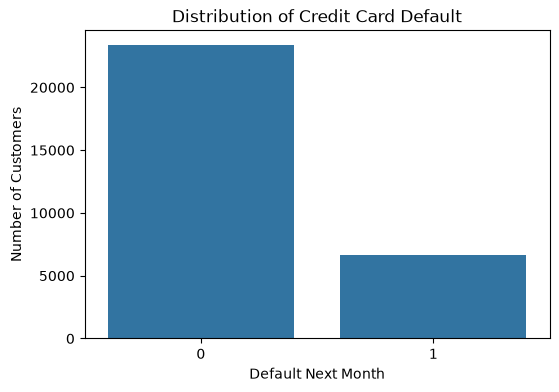

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x=target)

plt.title("Distribution of Credit Card Default")
plt.xlabel("Default Next Month")
plt.ylabel("Number of Customers")

plt.show()

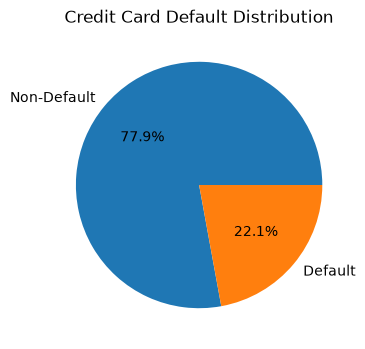

In [16]:
target_counts = df[target].value_counts()

plt.figure(figsize=(6, 4))

plt.pie(
    target_counts,
    labels=["Non-Default", "Default"],
    autopct="%1.1f%%"
)

plt.title("Credit Card Default Distribution")

plt.show()

Define Feature Groups

In [17]:
demographic_cols = [
    "SEX",
    "EDUCATION",
    "MARRIAGE",
    "AGE"
]

pay_cols = [
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6"
]

bill_cols = [
    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6"
]

pay_amt_cols = [
    "PAY_AMT1",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6"
]

financial_cols = [
    "LIMIT_BAL"
] + bill_cols + pay_amt_cols

In [18]:
# Categorical Variable Analysis

categorical_cols = ["SEX", "EDUCATION", "MARRIAGE"]

for col in categorical_cols:
    print("=" * 50)
    print(df[col].value_counts().sort_index())

SEX
1    11888
2    18112
Name: count, dtype: int64
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64


In [19]:
# Default Rate by Demographic Variables

for col in categorical_cols:
    print("=" * 60)
    print(f"Default rate by {col}")
    print((df.groupby(col)[target].mean() * 100).round(2))

Default rate by SEX
SEX
1    24.17
2    20.78
Name: default payment next month, dtype: float64
Default rate by EDUCATION
EDUCATION
0     0.00
1    19.23
2    23.73
3    25.16
4     5.69
5     6.43
6    15.69
Name: default payment next month, dtype: float64
Default rate by MARRIAGE
MARRIAGE
0     9.26
1    23.47
2    20.93
3    26.01
Name: default payment next month, dtype: float64


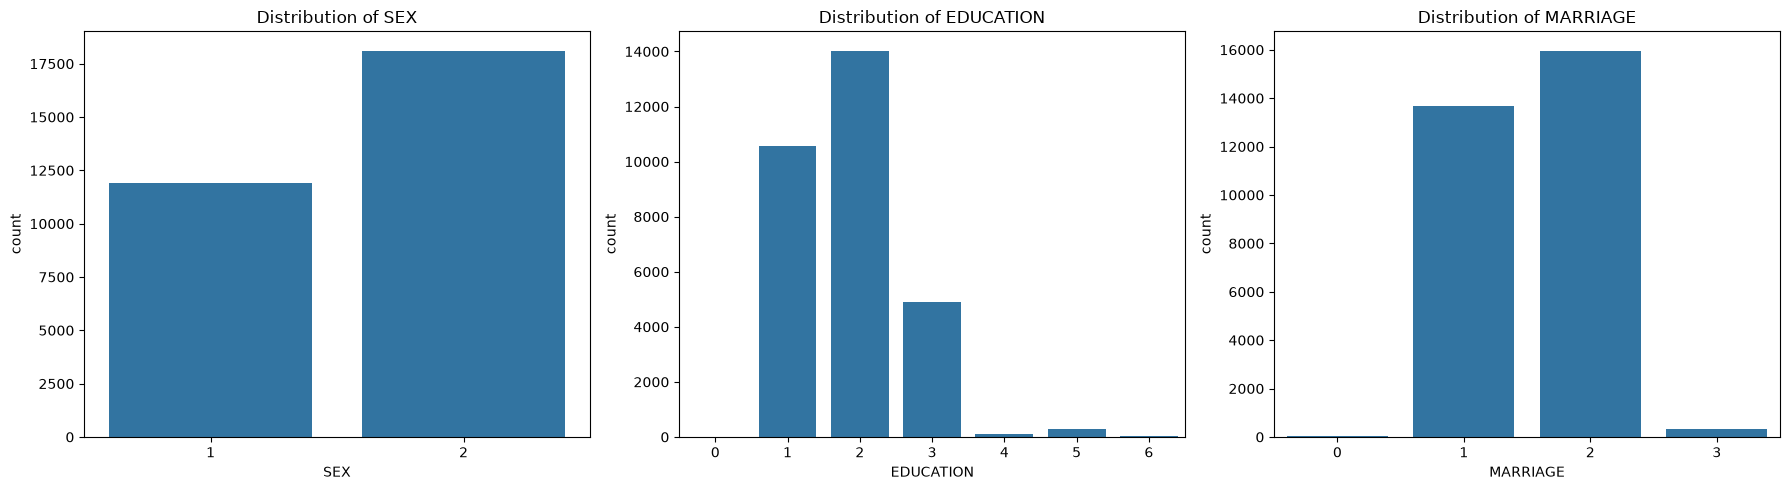

In [20]:
# Visualize Demographic Variables

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, categorical_cols):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

Age Analysis


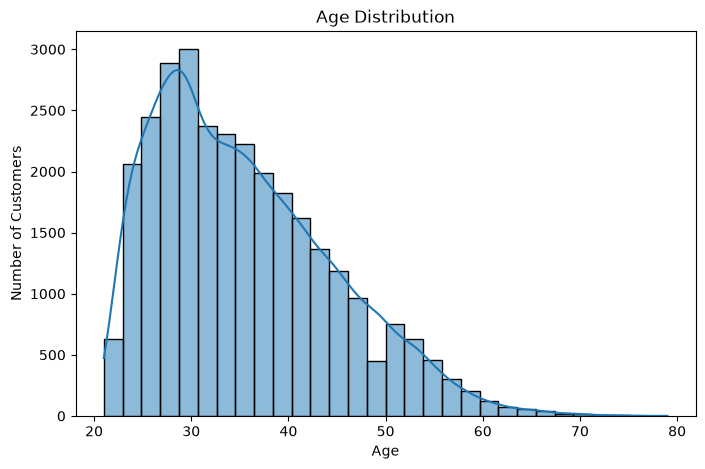

In [21]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="AGE", bins=30, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

In [22]:
df["AGE"].describe()

count    30000.000000
mean        35.485500
std          9.217904
min         21.000000
25%         28.000000
50%         34.000000
75%         41.000000
max         79.000000
Name: AGE, dtype: float64

In [23]:
# Age Groups

df["AGE_GROUP"] = pd.cut(
    df["AGE"],
    bins=[20, 30, 40, 50, 60, 80],
    labels=["21-30", "31-40", "41-50", "51-60", "61-79"]
)

print(df["AGE_GROUP"].value_counts().sort_index())

AGE_GROUP
21-30    11013
31-40    10713
41-50     6005
51-60     1997
61-79      272
Name: count, dtype: int64


In [24]:
age_default_rate = (
    df.groupby("AGE_GROUP", observed=False)[target]
    .mean() * 100
)

print(age_default_rate.round(2))

AGE_GROUP
21-30    22.44
31-40    20.43
41-50    23.30
51-60    25.24
61-79    26.84
Name: default payment next month, dtype: float64


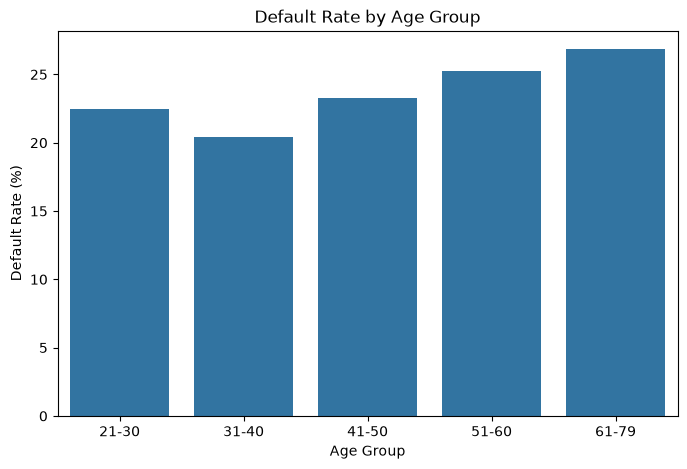

In [25]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=age_default_rate.index,
    y=age_default_rate.values
)

plt.title("Default Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Default Rate (%)")

plt.show()

Payment Status Analysis

In [26]:
for col in pay_cols:
    print("=" * 50)
    print(col)
    print(df[col].value_counts().sort_index())

PAY_0
PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64
PAY_2
PAY_2
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64
PAY_3
PAY_3
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64
PAY_4
PAY_4
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64
PAY_5
PAY_5
-2     4546
-1     5539
 0    16947
 2     2626
 3      178
 4       84
 5       17
 6        4
 7       58
 8        1
Name: count, dtype: int64
PAY_6
PAY_6
-2     4895
-1     5740
 0    16286
 2     2766
 3      184
 4       49
 5       13
 6       19
 7       46
 8        2
Name: count, dtype: int64


In [27]:
for col in pay_cols:
    print(f"\nDefault rate by {col}:")
    print(
        (df.groupby(col)[target].mean() * 100)
        .round(2)
    )


Default rate by PAY_0:
PAY_0
-2    13.23
-1    16.78
 0    12.81
 1    33.95
 2    69.14
 3    75.78
 4    68.42
 5    50.00
 6    54.55
 7    77.78
 8    57.89
Name: default payment next month, dtype: float64

Default rate by PAY_2:
PAY_2
-2    18.27
-1    15.97
 0    15.91
 1    17.86
 2    55.61
 3    61.66
 4    50.51
 5    60.00
 6    75.00
 7    60.00
 8     0.00
Name: default payment next month, dtype: float64

Default rate by PAY_3:
PAY_3
-2    18.53
-1    15.59
 0    17.45
 1    25.00
 2    51.56
 3    57.50
 4    57.89
 5    57.14
 6    60.87
 7    81.48
 8    66.67
Name: default payment next month, dtype: float64

Default rate by PAY_4:
PAY_4
-2    19.25
-1    15.90
 0    18.33
 1    50.00
 2    52.33
 3    61.11
 4    66.67
 5    51.43
 6    40.00
 7    82.76
 8    50.00
Name: default payment next month, dtype: float64

Default rate by PAY_5:
PAY_5
-2     19.69
-1     16.19
 0     18.85
 2     54.19
 3     63.48
 4     60.71
 5     58.82
 6     75.00
 7     82.76
 8    100

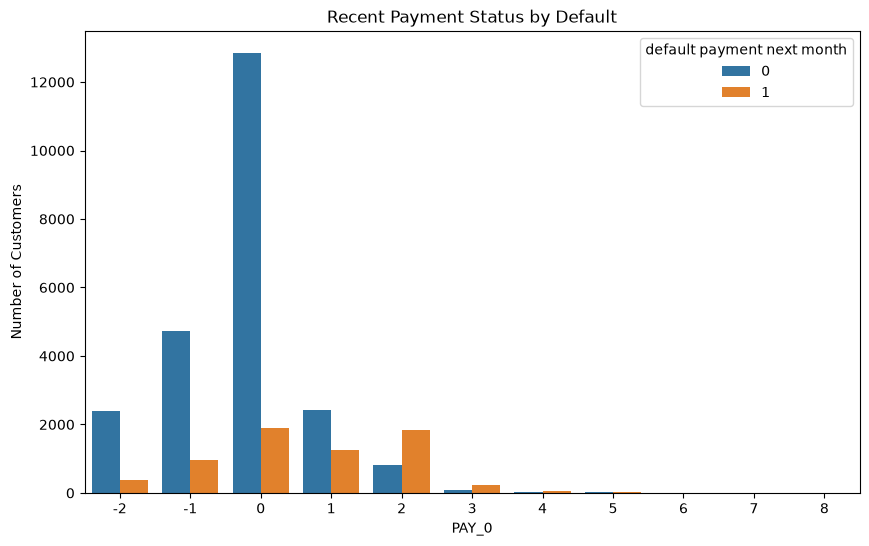

In [28]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="PAY_0",
    hue=target
)

plt.title("Recent Payment Status by Default")
plt.xlabel("PAY_0")
plt.ylabel("Number of Customers")

plt.show()

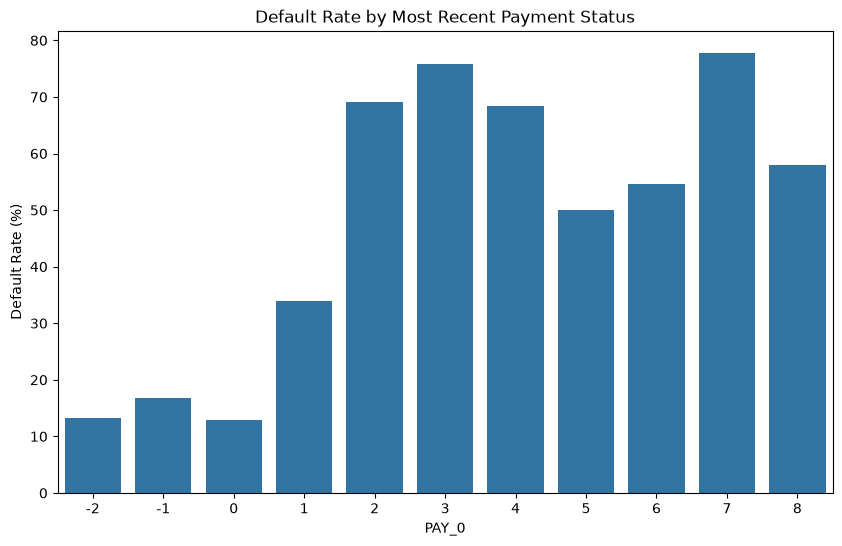

In [29]:
pay0_default_rate = (
    df.groupby("PAY_0")[target].mean() * 100
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=pay0_default_rate.index,
    y=pay0_default_rate.values
)

plt.title("Default Rate by Most Recent Payment Status")
plt.xlabel("PAY_0")
plt.ylabel("Default Rate (%)")

plt.show()

Credit Limit Analysis

In [30]:
df["LIMIT_BAL"].describe()

count      30000.000000
mean      167484.322667
std       129747.661567
min        10000.000000
25%        50000.000000
50%       140000.000000
75%       240000.000000
max      1000000.000000
Name: LIMIT_BAL, dtype: float64

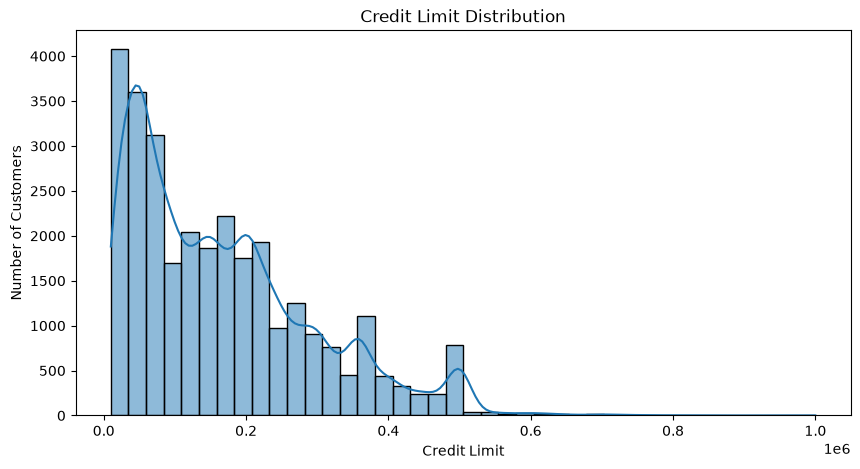

In [31]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="LIMIT_BAL",
    bins=40,
    kde=True
)

plt.title("Credit Limit Distribution")
plt.xlabel("Credit Limit")
plt.ylabel("Number of Customers")

plt.show()

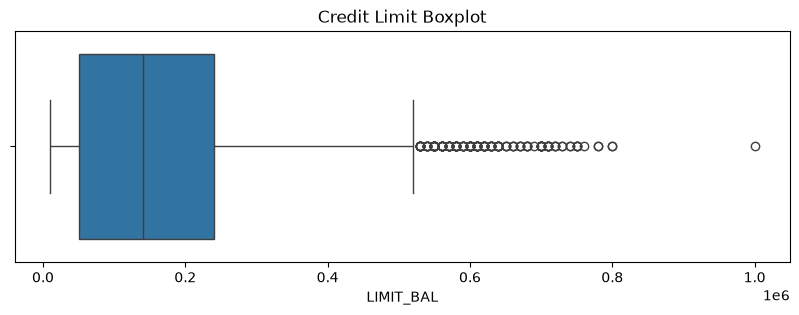

In [32]:
plt.figure(figsize=(10, 3))

sns.boxplot(x=df["LIMIT_BAL"])

plt.title("Credit Limit Boxplot")

plt.show()

Bill Amount Analysis

In [33]:
df[bill_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
BILL_AMT1,30000.0,51223.330900,73635.860576,-165580.0,3558.75,22381.5,67091.00,964511.0
BILL_AMT2,30000.0,49179.075167,71173.768783,-69777.0,2984.75,21200.0,64006.25,983931.0
BILL_AMT3,30000.0,47013.154800,69349.387427,-157264.0,2666.25,20088.5,60164.75,1664089.0
BILL_AMT4,30000.0,43262.948967,64332.856134,-170000.0,2326.75,19052.0,54506.00,891586.0
BILL_AMT5,30000.0,40311.400967,60797.155770,-81334.0,1763.00,18104.5,50190.50,927171.0
BILL_AMT6,30000.0,38871.760400,59554.107537,-339603.0,1256.00,17071.0,49198.25,961664.0


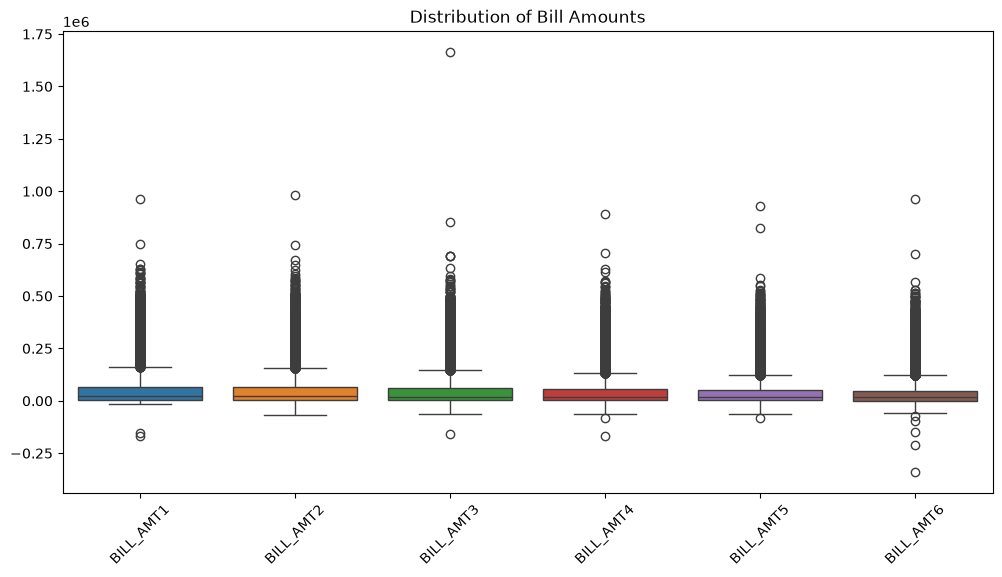

In [34]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df[bill_cols])

plt.title("Distribution of Bill Amounts")

plt.xticks(rotation=45)

plt.show()

In [35]:
for col in bill_cols:
    print(
        col,
        "Negative values:",
        (df[col] < 0).sum(),
        "Zero values:",
        (df[col] == 0).sum()
    )

BILL_AMT1 Negative values: 590 Zero values: 2008
BILL_AMT2 Negative values: 669 Zero values: 2506
BILL_AMT3 Negative values: 655 Zero values: 2870
BILL_AMT4 Negative values: 675 Zero values: 3195
BILL_AMT5 Negative values: 655 Zero values: 3506
BILL_AMT6 Negative values: 688 Zero values: 4020


Previous Payment Amount Analysis

In [36]:
df[pay_amt_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
PAY_AMT1,30000.0,5663.580500,16563.280354,0.0,1000.00,2100.0,5006.00,873552.0
PAY_AMT2,30000.0,5921.163500,23040.870402,0.0,833.00,2009.0,5000.00,1684259.0
PAY_AMT3,30000.0,5225.681500,17606.961470,0.0,390.00,1800.0,4505.00,896040.0
PAY_AMT4,30000.0,4826.076867,15666.159744,0.0,296.00,1500.0,4013.25,621000.0
PAY_AMT5,30000.0,4799.387633,15278.305679,0.0,252.50,1500.0,4031.50,426529.0
PAY_AMT6,30000.0,5215.502567,17777.465775,0.0,117.75,1500.0,4000.00,528666.0


In [37]:
for col in pay_amt_cols:
    print(
        col,
        "Zero values:",
        (df[col] == 0).sum()
    )

PAY_AMT1 Zero values: 5249
PAY_AMT2 Zero values: 5396
PAY_AMT3 Zero values: 5968
PAY_AMT4 Zero values: 6408
PAY_AMT5 Zero values: 6703
PAY_AMT6 Zero values: 7173


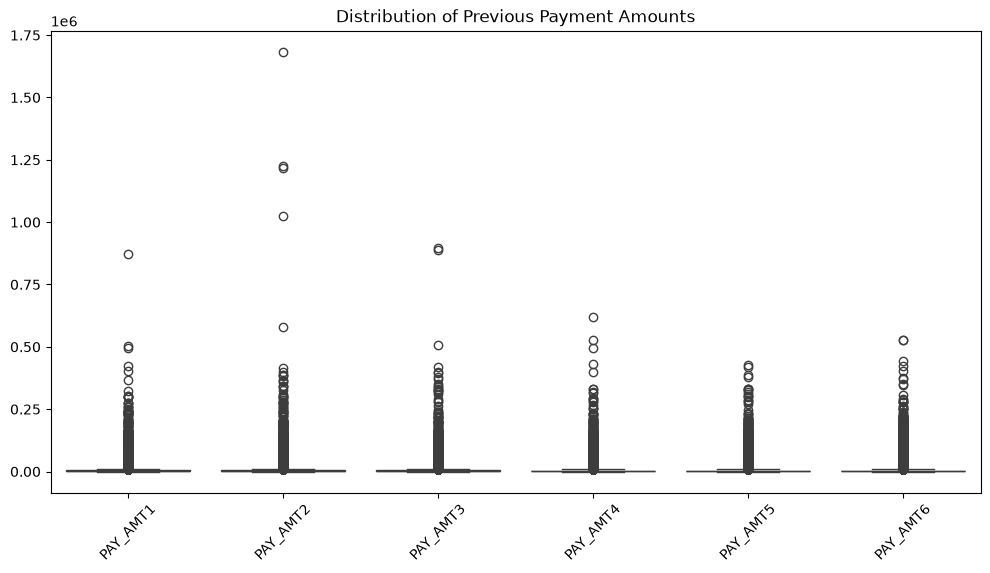

In [38]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df[pay_amt_cols])

plt.title("Distribution of Previous Payment Amounts")

plt.xticks(rotation=45)

plt.show()

Outlier Analysis

In [39]:
Q1 = df[financial_cols].quantile(0.25)
Q3 = df[financial_cols].quantile(0.75)

IQR = Q3 - Q1

outlier_counts = (
    (df[financial_cols] < (Q1 - 1.5 * IQR)) |
    (df[financial_cols] > (Q3 + 1.5 * IQR))
).sum()

print("Potential outliers:")
print(outlier_counts.sort_values(ascending=False))

Potential outliers:
PAY_AMT4     2994
PAY_AMT6     2958
PAY_AMT5     2945
PAY_AMT1     2745
BILL_AMT5    2725
PAY_AMT2     2714
BILL_AMT6    2693
BILL_AMT4    2622
PAY_AMT3     2598
BILL_AMT3    2469
BILL_AMT1    2400
BILL_AMT2    2395
LIMIT_BAL     167
dtype: int64


Zero-Value Analysis

In [40]:
zero_summary = pd.DataFrame({
    "Zero Count": (df[financial_cols] == 0).sum(),
    "Zero Percentage": ((df[financial_cols] == 0).mean() * 100).round(2)
})

zero_summary

,Zero Count,Zero Percentage
LIMIT_BAL,0,0.00
BILL_AMT1,2008,6.69
BILL_AMT2,2506,8.35
BILL_AMT3,2870,9.57
BILL_AMT4,3195,10.65
BILL_AMT5,3506,11.69
BILL_AMT6,4020,13.40
PAY_AMT1,5249,17.50
PAY_AMT2,5396,17.99
PAY_AMT3,5968,19.89


Correlation Analysis

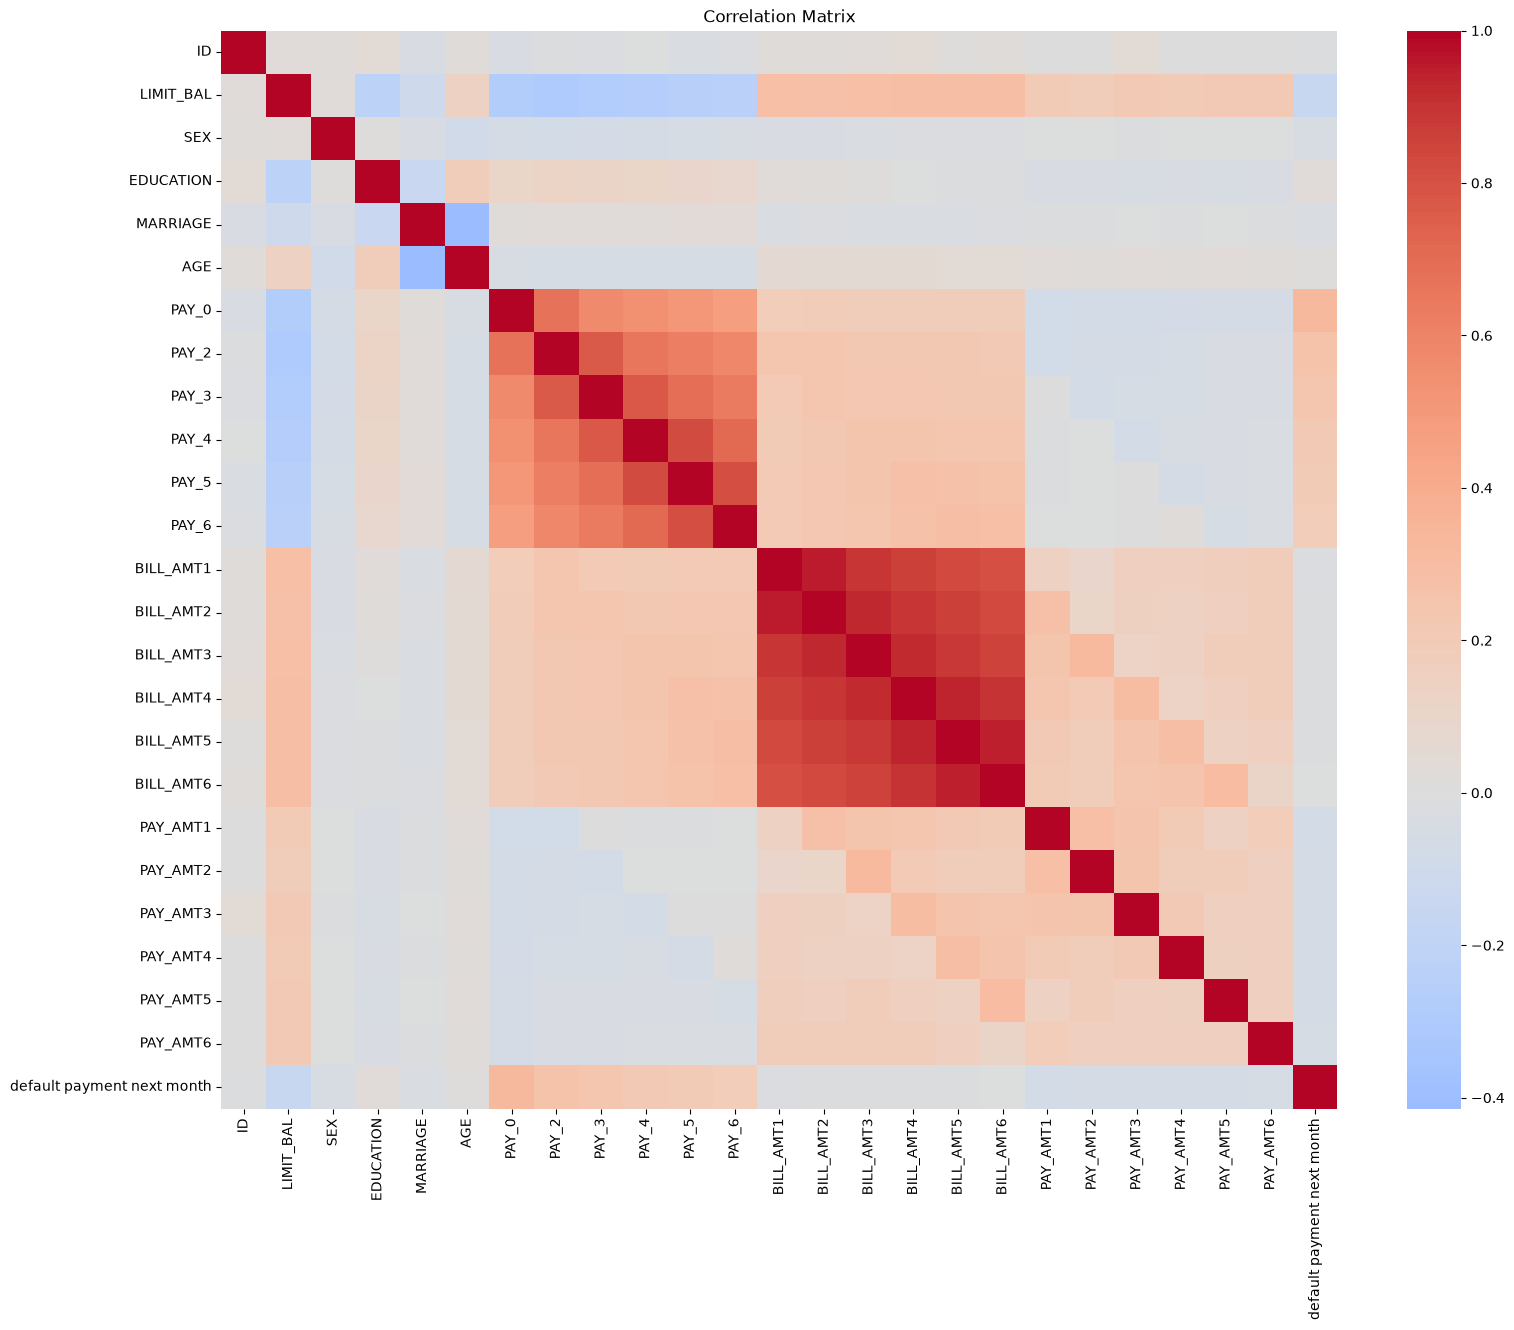

In [41]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(18, 14))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

In [42]:
target_correlation = (
    corr[target]
    .sort_values(ascending=False)
)

print(target_correlation)

default payment next month    1.000000
PAY_0                         0.324794
PAY_2                         0.263551
PAY_3                         0.235253
PAY_4                         0.216614
PAY_5                         0.204149
PAY_6                         0.186866
EDUCATION                     0.028006
AGE                           0.013890
BILL_AMT6                    -0.005372
BILL_AMT5                    -0.006760
BILL_AMT4                    -0.010156
ID                           -0.013952
BILL_AMT3                    -0.014076
BILL_AMT2                    -0.014193
BILL_AMT1                    -0.019644
MARRIAGE                     -0.024339
SEX                          -0.039961
PAY_AMT6                     -0.053183
PAY_AMT5                     -0.055124
PAY_AMT3                     -0.056250
PAY_AMT4                     -0.056827
PAY_AMT2                     -0.058579
PAY_AMT1                     -0.072929
LIMIT_BAL                    -0.153520
Name: default payment nex

Default Rate vs Credit Limit

In [43]:
df["LIMIT_BAL_GROUP"] = pd.qcut(
    df["LIMIT_BAL"],
    q=5,
    duplicates="drop"
)

In [44]:
limit_default_rate = (
    df.groupby("LIMIT_BAL_GROUP", observed=False)[target]
    .mean() * 100
)

print(limit_default_rate.round(2))

LIMIT_BAL_GROUP
(9999.999, 50000.0]      31.79
(50000.0, 100000.0]      25.80
(100000.0, 180000.0]     19.86
(180000.0, 270000.0]     16.86
(270000.0, 1000000.0]    13.80
Name: default payment next month, dtype: float64


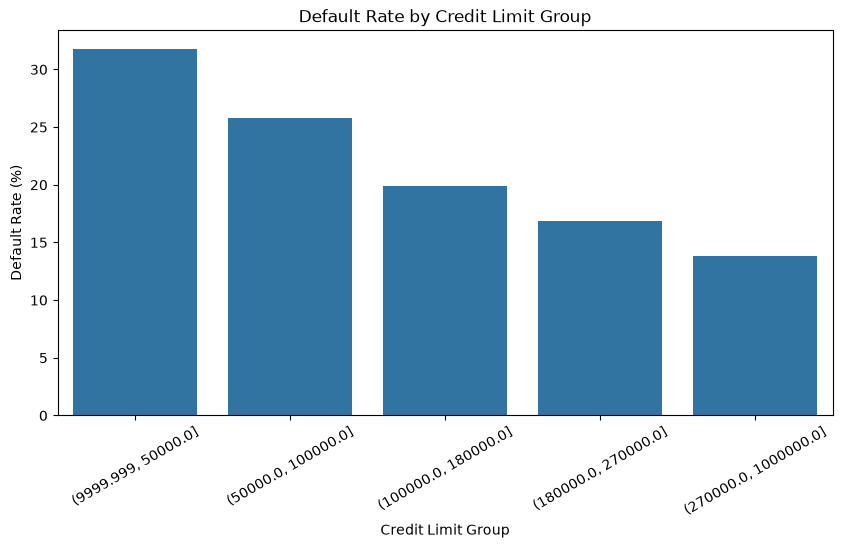

In [45]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=limit_default_rate.index.astype(str),
    y=limit_default_rate.values
)

plt.title("Default Rate by Credit Limit Group")
plt.xlabel("Credit Limit Group")
plt.ylabel("Default Rate (%)")

plt.xticks(rotation=30)

plt.show()